In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from prismg.io import vcf_reader as vcfio
from prismg.utils.grm import standardize_by_af, compute_grm
from prismg.metrics.pli import compute_pli
from prismg.metrics.kri import compute_kri
from prismg.metrics.tli import compute_tli
from prismg.score import r_raw, calibrate_to_prism, choose_targets_from_anchors, fit_weights_anchor
from prismg.bootstrap import bootstrap_analysis, grid_search


### PRISM-G parameters for metrics

In [2]:
RANDOM_SEED   = 123
TRAIN_FRAC    = 0.8

# Parameters for PLI 
N_COMPONENTS  = 10
Q_LOWER       = 0.01

# Parameters for KRI
THETA_REPLAY = 0.125
REPLAY_N_BINS = 25
REPLAY_UPPER = 0.5
IKE_THETAS   = (0.1, 0.125, 0.25)
N_BOOT       = 10

# Parameters for TLI
RARE_MAF = 1e-3
ALPHA_AF = 1e-3
K_MINOR = 0

### Data input

In [3]:
# ==================== Paths ====================
# Datasets
REAL_VCF = "example_data/1000G_10K_SNP_chr15.vcf.gz"
GAN_VCF  = "example_data/GAN_10K_SNP_chr15.vcf.gz"
RBM_VCF  = "example_data/RBM_10K_SNP_chr15.vcf.gz"
GENOMATOR_H1_VCF = "example_data/GENOMATOR_10K_chr15.vcf.gz"
GENOMATOR_H10_VCF = "example_data/GENOMATOR_10K_H10_chr15.vcf.gz"
GENOMATOR_H50_VCF = "example_data/GENOMATOR_10K_H50_chr15.vcf.gz"

# Calibrators
LEAKY_VCF = "example_data/LEAKY_kindoped_chr15.vcf.gz"
SAFE_VCF = "example_data/SAFE_chr15_binomial_panel.vcf.gz"

# SNP Positions
LEGEND   = "example_data/10K_SNP.legend"

In [4]:
legend_keys = vcfio.load_snp_legend_pos_keys(LEGEND)
real_samples, real_meta, real_G = vcfio.load_vcf(REAL_VCF, keep_pos=legend_keys)
gan_samples,  gan_meta,  gan_G  = vcfio.load_vcf(GAN_VCF,  keep_pos=legend_keys)
rbm_samples,  rbm_meta,  rbm_G  = vcfio.load_vcf(RBM_VCF,  keep_pos=legend_keys)
genom_h1_samples,  genom_h1_meta,  genom_h1_G  = vcfio.load_vcf(GENOMATOR_H1_VCF,  keep_pos=legend_keys)
genom_h10_samples,  genom_h10_meta,  genom_h10_G  = vcfio.load_vcf(GENOMATOR_H10_VCF,  keep_pos=legend_keys)
genom_h50_samples,  genom_h50_meta,  genom_h50_G  = vcfio.load_vcf(GENOMATOR_H50_VCF,  keep_pos=legend_keys)

leaky_samples,  leaky_meta,  leaky_G  = vcfio.load_vcf(LEAKY_VCF,  keep_pos=legend_keys)
safe_samples,  safe_meta,  safe_G  = vcfio.load_vcf(SAFE_VCF,  keep_pos=legend_keys)

In [5]:
# ==================== Train/Holdout split ====================
rng = np.random.RandomState(RANDOM_SEED)
idx = np.arange(len(real_samples))
rng.shuffle(idx)
cut = int(len(idx) * TRAIN_FRAC)
tr_idx, ho_idx = idx[:cut], idx[cut:]

R_tr_samples = [real_samples[i] for i in tr_idx]
R_ho_samples = [real_samples[i] for i in ho_idx]
G_tr, G_ho   = real_G[tr_idx, :], real_G[ho_idx, :]

print(f"(TRAIN={len(R_tr_samples)}, HOLDOUT={len(R_ho_samples)})")

(TRAIN=2003, HOLDOUT=501)


### Proximity leakage index

In [6]:
_pli_kwargs = dict(
    n_components = N_COMPONENTS,
    random_state = RANDOM_SEED,
    q            = Q_LOWER,
)

_GENERATORS = [
    ("GAN",           gan_G),
    ("RBM",           rbm_G),
    ("Genomator_H1",  genom_h1_G),
    ("Genomator_H10", genom_h10_G),
    ("Genomator_H50", genom_h50_G),
    ("Leaky Copycat", leaky_G),
    ("Safe binomial", safe_G),
]

_SCORE_KEYS = ("rho_q", "r_p", "A", "r_A", "PLI")

pli_df = pd.DataFrame([
    {"dataset": label, **{k: compute_pli(G_tr, G_ho, gen, **_pli_kwargs)[k] for k in _SCORE_KEYS}}
    for label, gen in _GENERATORS
]).set_index("dataset").round(4)

display(pli_df)

,rho_q,r_p,A,r_A,PLI
dataset,,,,,
GAN,1.0530,0.0000,0.3493,0.3014,0.3014
RBM,1.0986,0.0000,0.3273,0.3453,0.3453
Genomator_H1,0.1913,0.8087,0.0858,0.8283,0.8283
Genomator_H10,0.4122,0.5878,0.0958,0.8084,0.8084
Genomator_H50,0.7379,0.2621,0.1337,0.7325,0.7325
Leaky Copycat,0.0000,1.0000,0.0739,0.8523,1.0000
Safe binomial,3.3639,0.0000,0.9940,0.0000,0.0000


### Kinship replay index

In [7]:
var_chr = [chrom for chrom, pos, ref, alt in real_meta]

# ── Run KRI for all generators ────────────────────────────────────────────────
_kri_kwargs = dict(
    theta        = THETA_REPLAY,
    replay_n_bins= REPLAY_N_BINS,
    replay_upper = REPLAY_UPPER,
    ike_thetas   = IKE_THETAS,
    n_boot       = N_BOOT,
    seed         = RANDOM_SEED,
)

_SCORE_KEYS = ("r_replay", "r_IKE", "r_HAP", "r_SPEC", "KRI")

kri_df = pd.DataFrame([
    {"dataset": label, **{k: compute_kri(G_tr, G_ho, gen, var_chr, **_kri_kwargs)[k] for k in _SCORE_KEYS}}
    for label, gen in _GENERATORS
]).set_index("dataset").round(4)

display(kri_df)

,r_replay,r_IKE,r_HAP,r_SPEC,KRI
dataset,,,,,
GAN,0.0000,0.2655,0.0071,0.4354,0.4354
RBM,0.0000,0.0000,0.0306,0.0000,0.0306
Genomator_H1,0.5532,0.0000,0.0123,0.7504,0.7504
Genomator_H10,0.6649,0.0188,0.0166,0.7889,0.7889
Genomator_H50,0.6572,0.0557,0.0415,0.8134,0.8134
Leaky Copycat,0.0000,0.0411,0.0000,0.2060,0.2060
Safe binomial,0.0000,0.0000,0.0000,0.0000,0.0000


### Trait-linked leakage index

In [8]:
_tli_kwargs = dict(
    maf_thresh = RARE_MAF,
    alpha = ALPHA_AF,
    k_minor = K_MINOR,
    min_train_calls_frac = TRAIN_FRAC,
)

_SCORE_KEYS = ("MIA_AUC", "r_mia", "U", "U0", "r_uniq", "TLI")

tli_df = pd.DataFrame([
    {"dataset": label, **{k: compute_tli(G_tr, G_ho, gen, var_chr, **_tli_kwargs)[k] for k in _SCORE_KEYS}}
    for label, gen in _GENERATORS
]).set_index("dataset").round(4)

display(tli_df)

,MIA_AUC,r_mia,U,U0,r_uniq,TLI
dataset,,,,,,
GAN,0.4831,0.0000,0.6639,0.5387,0.2713,0.2713
RBM,0.5002,0.0005,0.9052,0.5387,0.7944,0.7944
Genomator_H1,0.5195,0.0390,0.0084,0.5381,0.0000,0.0390
Genomator_H10,0.5119,0.0238,0.0049,0.5381,0.0000,0.0238
Genomator_H50,0.5175,0.0349,0.0031,0.5381,0.0000,0.0349
Leaky Copycat,0.5000,0.0000,1.0000,0.5381,1.0000,1.0000
Safe binomial,0.5061,0.0121,0.5289,0.5381,0.0000,0.0121


### Compute PRISM-G score

In [9]:
scores = [
    {"name": "GAN", "pli": 0.301, "kri": 0.435, "tli": 0.271, "role": "candidate"},
    {"name": "RBM", "pli": 0.345, "kri": 0.0317, "tli": 0.794, "role": "candidate"},
    {"name": "GENOMATOR_H1", "pli": 0.828, "kri": 0.7504, "tli": 0.0390, "role": "candidate"},
    {"name": "GENOMATOR_H10", "pli": 0.808, "kri":0.7889, "tli": 0.024, "role": "candidate"},
    {"name": "GENOMATOR_H50", "pli": 0.733, "kri": 0.8134, "tli": 0.035, "role": "candidate"},


    {"name": "Safe binomial",   "pli": 0.0000, "kri": 0.0045, "tli": 0.012, "role": "safe anchor"},
    {"name": "Leaky kindoped",  "pli": 1.0000, "kri": 0.206, "tli": 1.0000,   "role": "leaky anchor"},
]
scores_df = pd.DataFrame(scores)

In [10]:
r_safe = [0.0, 0.007, 0.012]
r_leak = [1, 0.206, 1]

eps, lam = choose_targets_from_anchors([r_safe], [r_leak])
w_star = fit_weights_anchor(r_safe, r_leak, eps=0.02, lam=0.75, gamma=1e-3, step=0.01)
print(w_star)

[0.22 0.11 0.67]


In [11]:
# Compute R_raw for each row
scores_df["R_raw"] = scores_df.apply(lambda r: r_raw([r.pli, r.kri, r.tli], w_star), axis=1)

alpha = scores_df.loc[scores_df["name"] == "Safe binomial", "R_raw"].iloc[0]
beta  = scores_df.loc[scores_df["name"] == "Leaky kindoped", "R_raw"].iloc[0]

In [12]:
scores_df["PRISM_G"] = scores_df.apply(
    lambda r: calibrate_to_prism(r.R_raw, alpha, beta),
    axis=1)

# Pretty print
print(f"alpha (safe)  = {alpha:.5f}")
print(f"beta  (leaky) = {beta:.5f}\n")

display(scores_df)

alpha (safe)  = 0.00853
beta  (leaky) = 0.74843



,name,pli,kri,tli,role,R_raw,PRISM_G
0,GAN,0.301,0.4350,0.271,candidate,0.272335,35.653926
1,RBM,0.345,0.0317,0.794,candidate,0.569011,75.750582
2,GENOMATOR_H1,0.828,0.7504,0.039,candidate,0.269274,35.240216
3,GENOMATOR_H10,0.808,0.7889,0.024,candidate,0.261187,34.147295
4,GENOMATOR_H50,0.733,0.8134,0.035,candidate,0.254214,33.204823
5,Safe binomial,0.000,0.0045,0.012,safe anchor,0.008531,0.000000
6,Leaky kindoped,1.000,0.2060,1.000,leaky anchor,0.748433,100.000000


(<Figure size 1440x800 with 2 Axes>,
 <Axes: ylabel='PRISM-G (0 = safer, 100 = riskier)'>)

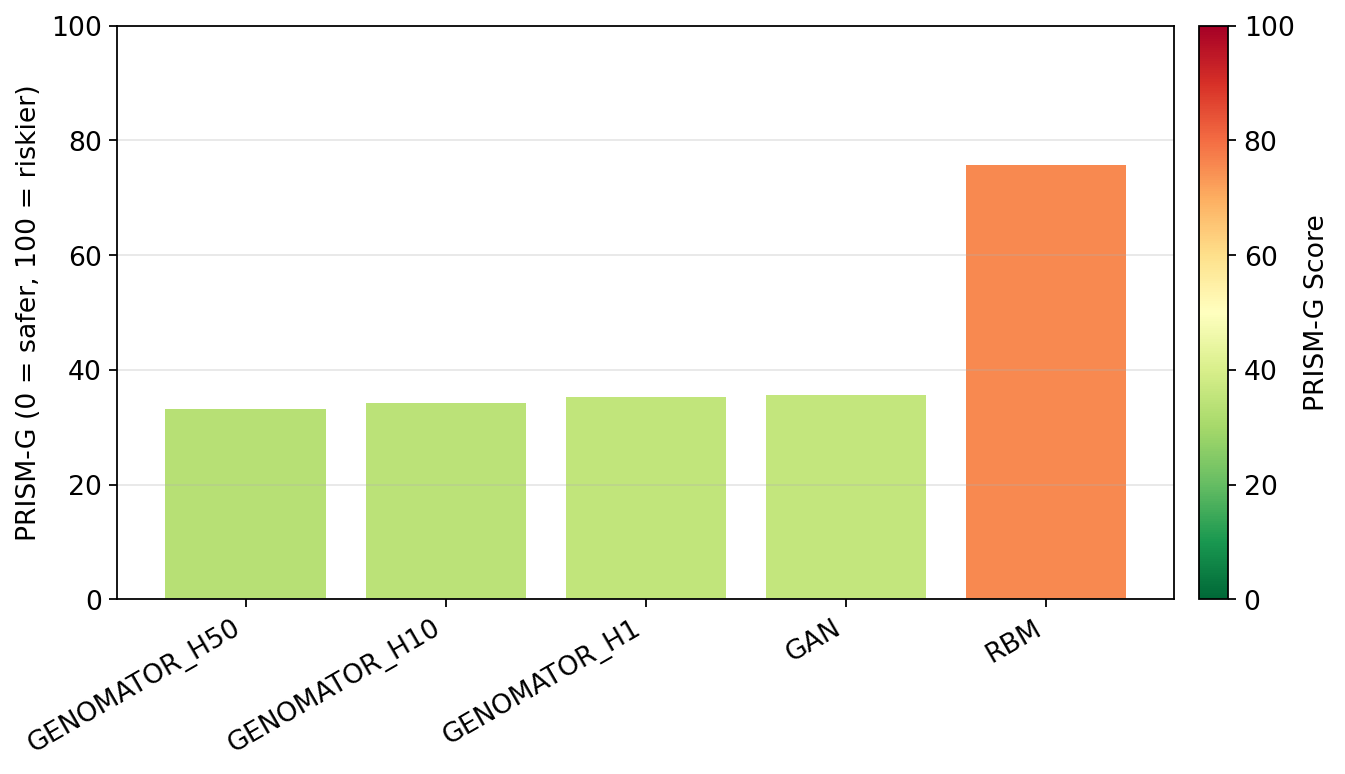

In [13]:
from prismg.utils import plotting
plotting.plot_prismg_summary(scores_df)

### Bootstrapping and pairwise comparison

In [14]:
eps = 0.02
lam = 0.75
gamma = 0.001
w0 = [0,0,0]

weights_info, tblR, tblG, tblP, ranks, kend, boot_G = bootstrap_analysis(scores_df, B=100, sigma=0.01, eps=eps, lam=lam, gamma=gamma, w0=w0, 
                                                                         refit_weights=True, step=0.01, random_state=RANDOM_SEED)

if isinstance(weights_info, dict):
    print("Weights (refit each draw): mean ± sd  [n={}]:".format(weights_info["n"]))
    print(np.round(weights_info["mean"], 4), "±", np.round(weights_info["sd"], 4))
else:
    print("Baseline weights (fixed):", np.round(weights_info, 4))

print("\nBootstrap PRISM-G (means ± sd):")
print(tblG[["name","mean_G","sd_G","ci95_G_lo","ci95_G_hi"]].round(3).to_string(index=False))

print("\nPairwise PRISM-G differences (two-sided p-values):")
print(tblP[["A_minus_B","mean_diff","ci95_diff_lo","ci95_diff_hi", "p_two_sided","p_fmt"]].to_string(index=False))
print(kend)

Weights (refit each draw): mean ± sd  [n=100]:
[0.3598 0.0671 0.5731] ± [0.156  0.0392 0.1413]

Bootstrap PRISM-G (means ± sd):
         name  mean_G   sd_G  ci95_G_lo  ci95_G_hi
          RBM  70.263  8.420     49.824     77.005
 GENOMATOR_H1  46.010 14.590     33.103     78.627
GENOMATOR_H10  44.540 14.378     32.145     76.991
GENOMATOR_H50  41.879 12.641     31.553     71.094
          GAN  35.188  1.014     33.585     37.321

Pairwise PRISM-G differences (two-sided p-values):
                    A_minus_B  mean_diff  ci95_diff_lo  ci95_diff_hi  p_two_sided     p_fmt
                    GAN - RBM -35.075022    -41.374362    -12.503614         0.00  <1x10^-2
 GENOMATOR_H1 - GENOMATOR_H10   1.470363      0.890892      1.927860         0.00  <1x10^-2
 GENOMATOR_H1 - GENOMATOR_H50   4.131239      1.264258      7.582922         0.00  <1x10^-2
GENOMATOR_H10 - GENOMATOR_H50   2.660876      0.373366      5.867432         0.04 4.0x10^-2
          RBM - GENOMATOR_H50  28.383923    -21.269965

### Grid search

In [15]:
# Define the grids you want to scan
eps_grid = [0.02, 0.04, 0.06, 0.08, 0.10]
lam_grid = [0.75, 0.80, 0.85, 0.90]
gamma_grid = [1e-4, 1e-3, 1e-2]

# Run the grid search (reusing your EXAMPLE_DATA DataFrame `df`)
res = grid_search(scores_df, eps_grid=eps_grid, lam_grid=lam_grid, gamma_grid=gamma_grid, B=10, sigma=0.01, w0=(0,0,0), step=0.01, 
                          refit_weights=True, random_state=RANDOM_SEED)

# See the top settings by mean Kendall τ
print(res.head(10).to_string(index=False))

 eps  lam  gamma  mean_tau   sd_tau  tau_ci_lo  tau_ci_hi  p_tau                                               modal_rank  modal_prop  N_boot  w_PLI_mean  w_KRI_mean  w_TLI_mean  w_PLI_sd  w_KRI_sd  w_TLI_sd
0.04 0.75  0.010      0.88 0.252982        0.4        1.0  0.018 RBM > GENOMATOR_H1 > GENOMATOR_H10 > GENOMATOR_H50 > GAN         0.8      10       0.397       0.048       0.555  0.103285  0.011353  0.096868
0.06 0.75  0.010      0.88 0.252982        0.4        1.0  0.018 RBM > GENOMATOR_H1 > GENOMATOR_H10 > GENOMATOR_H50 > GAN         0.8      10       0.377       0.058       0.565  0.119168  0.014757  0.110076
0.02 0.75  0.010      0.84 0.206559        0.6        1.0  0.018 RBM > GENOMATOR_H1 > GENOMATOR_H10 > GENOMATOR_H50 > GAN         0.6      10       0.453       0.036       0.511  0.094522  0.008433  0.088374
0.04 0.80  0.010      0.76 0.505964       -0.2        1.0  0.083 RBM > GAN > GENOMATOR_H1 > GENOMATOR_H10 > GENOMATOR_H50         0.8      10       0.337       0.029   

In [16]:
eps = 0.04
lam = 0.75
gamma = 0.01
w0 = [0,0,0]

weights_info, tblR, tblG, tblP, ranks, kend, boot_G = bootstrap_analysis(scores_df, B=100, sigma=0.01, eps=eps, lam=lam, gamma=gamma, w0=w0, 
                                                                         refit_weights=True, step=0.01, random_state=RANDOM_SEED)

if isinstance(weights_info, dict):
    print("Weights (refit each draw): mean ± sd  [n={}]:".format(weights_info["n"]))
    print(np.round(weights_info["mean"], 4), "±", np.round(weights_info["sd"], 4))
else:
    print("Baseline weights (fixed):", np.round(weights_info, 4))

print("\nBootstrap PRISM-G (means ± sd):")
print(tblG[["name","mean_G","sd_G","ci95_G_lo","ci95_G_hi"]].round(3).to_string(index=False))

print("\nPairwise PRISM-G differences (two-sided p-values):")
print(tblP[["A_minus_B","mean_diff","ci95_diff_lo","ci95_diff_hi", "p_two_sided","p_fmt"]].to_string(index=False))
print(kend)

Weights (refit each draw): mean ± sd  [n=100]:
[0.401  0.0482 0.5508] ± [0.1017 0.0149 0.0948]

Bootstrap PRISM-G (means ± sd):
         name  mean_G   sd_G  ci95_G_lo  ci95_G_hi
          RBM  69.568  5.738     57.155     74.633
 GENOMATOR_H1  49.338 10.175     39.682     70.904
GENOMATOR_H10  47.722 10.055     38.270     69.129
GENOMATOR_H50  44.492  8.873     36.332     63.623
          GAN  35.334  0.650     34.203     36.738

Pairwise PRISM-G differences (two-sided p-values):
                    A_minus_B  mean_diff  ci95_diff_lo  ci95_diff_hi  p_two_sided     p_fmt
                    GAN - RBM -34.234785    -39.675707    -20.587971         0.00  <1x10^-2
           GAN - GENOMATOR_H1 -14.004234    -34.260663     -4.317707         0.00  <1x10^-2
          GAN - GENOMATOR_H10 -12.388159    -32.481975     -2.939868         0.00  <1x10^-2
          GAN - GENOMATOR_H50  -9.158808    -26.961356     -1.081079         0.00  <1x10^-2
 GENOMATOR_H1 - GENOMATOR_H10   1.616075      1.404063

(<Figure size 1440x800 with 2 Axes>,
 <Axes: title={'center': 'Bootstrap PRISM-G'}, ylabel='PRISM-G (0 = safer, 100 = riskier)'>)

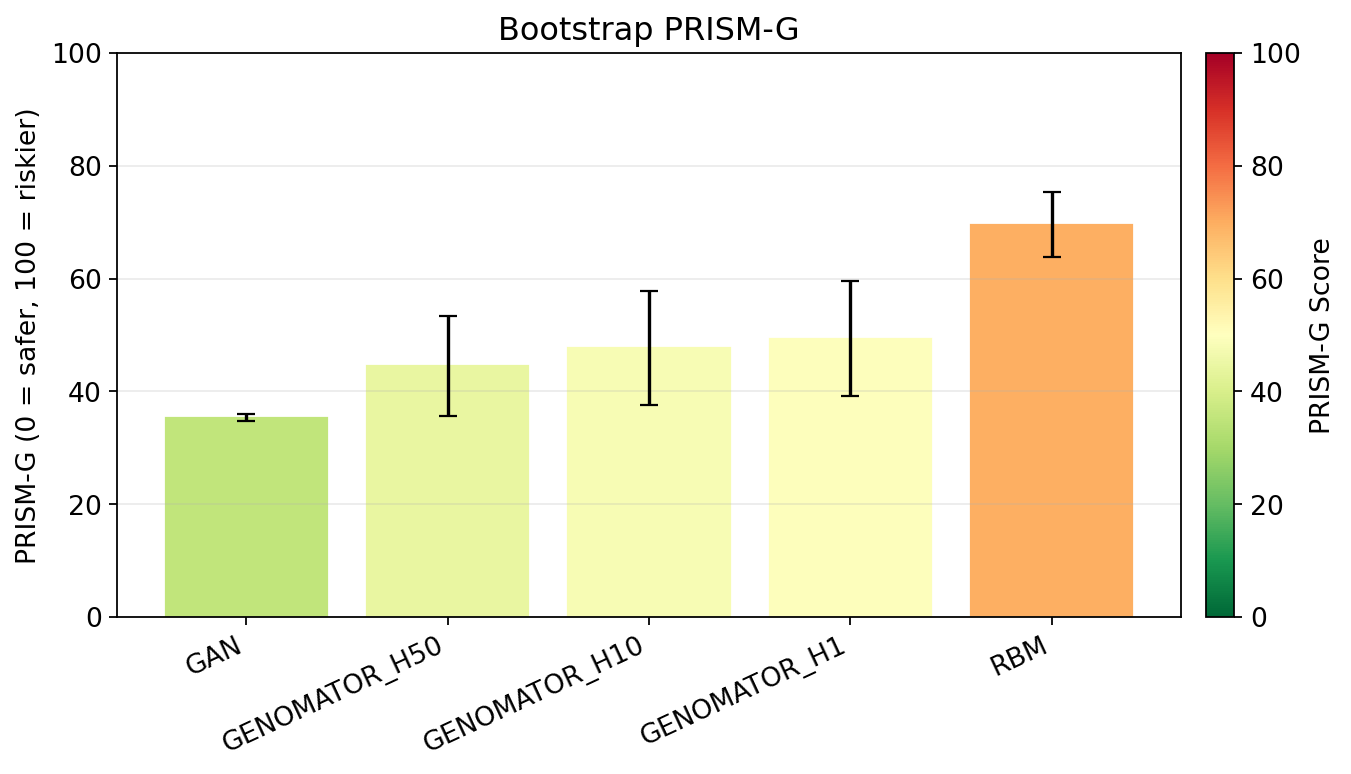

In [17]:
from prismg.utils import plotting
plotting.plot_boot_barplot(boot_G, tblG)

### Proximity diagnostics based on PLI metrics

In [18]:
from prismg.utils.diag import pli_diagnostics, plot_dsyn_dreal_per_sample, plot_identifiability_scatter

In [ ]:
diag = pli_diagnostics(G_tr, G_ho, genom_h50_G, ho_names=R_ho_samples, n_components=N_COMPONENTS, q=Q_LOWER, random_state=RANDOM_SEED, boot=N_BOOT)
print("Driver:", diag["driver"]) 
print("\nTop-10 most identifiable HO samples by proximity distance (PLI):")
print(diag["per_sample"].head(10).to_string(index=False))
 
print("\nBootstrap stability summary:")
print(diag["boot"].describe(percentiles=[0.025, 0.5, 0.975]).round(4).to_string())

Driver: adv_proximity

Top-10 most identifiable HO samples:
 sample    d_syn    d_real  ratio_dsyn_dreal  margin_dreal_minus_dsyn  s_ratio  ap_flag  rank_s_ratio  rank_margin
HG01350 4.514398 20.473181          0.220503                15.958783 0.779497        1             1            6
HG00115 5.019450 19.016281          0.263955                13.996832 0.736045        1             2           14
HG03940 8.111493 27.419786          0.295826                19.308293 0.704174        1             3            1
HG03631 6.767988 21.472291          0.315196                14.704303 0.684804        1             4            9
NA18910 4.954565 15.475613          0.320153                10.521048 0.679847        1             5           37
NA20799 6.806901 20.948285          0.324938                14.141384 0.675062        1             6           11
HG02139 6.383253 19.396706          0.329090                13.013453 0.670910        1             7           17
HG03772 8.980276 27.

c:\Users\acorrear\OneDrive - KU Leuven\Projects\prism-g\testing\utils\diag.py:239: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


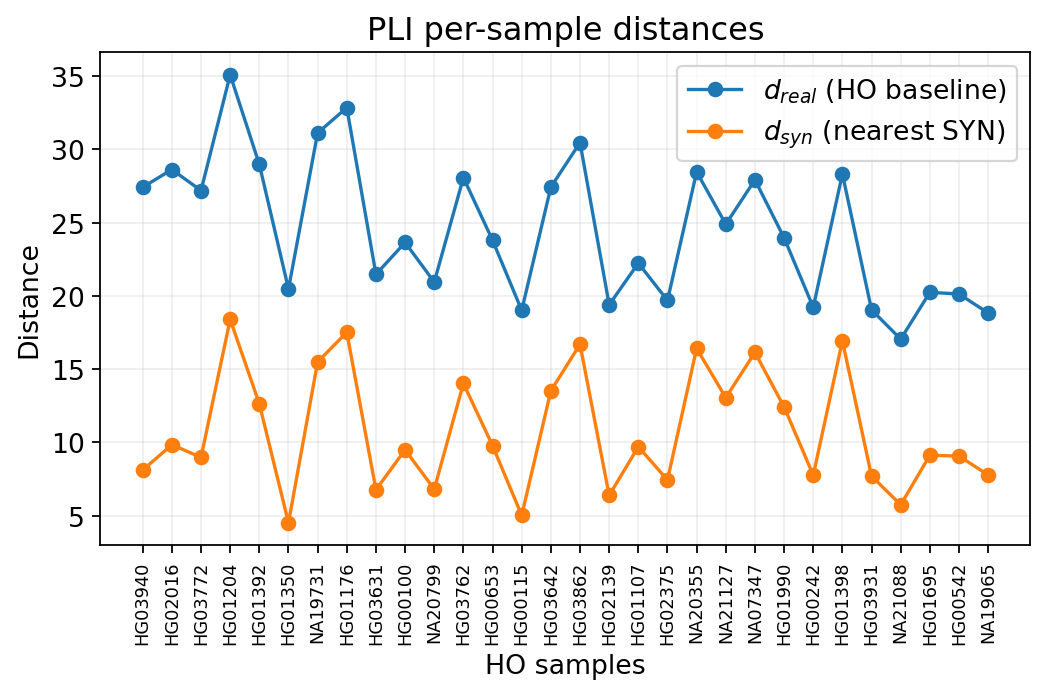

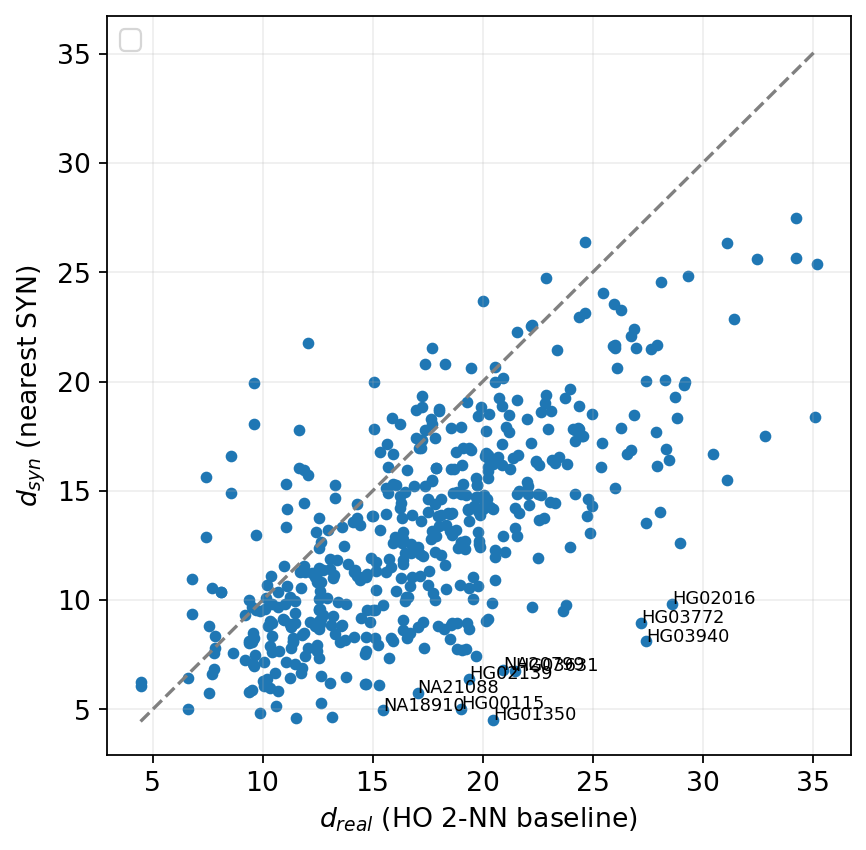

In [20]:
_, _, plot = plot_dsyn_dreal_per_sample(df=diag["per_sample"], sort_by="margin", title="PLI per-sample distances", top_k = 30)
_, _, plot = plot_identifiability_scatter(df=diag["per_sample"], annotate_top_k=10, title="PLI identifiability scatter")